**EDA on our merged OULAD**

In [4]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('ouladmerg.csv')

We look at what columns there are, and divide these into columns related to the unique student, columns related to VLE interactions, and columns related to assessments.

In [6]:
df.columns

Index(['id_student', 'code_module', 'code_presentation', 'date', 'forumng',
       'homepage', 'oucontent', 'subpage', 'url', 'resource', 'glossary',
       'dataplus', 'oucollaborate', 'quiz', 'ouelluminate', 'sharedsubpage',
       'questionnaire', 'page', 'externalquiz', 'ouwiki', 'dualpane',
       'repeatactivity', 'folder', 'htmlactivity', 'id_assessment',
       'is_banked', 'score', 'assessment_type', 'due_date', 'weight',
       'module_presentation_length', 'gender', 'region', 'highest_education',
       'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits',
       'disability', 'final_result', 'date_registration',
       'date_unregistration'],
      dtype='object')

In [7]:
tag_feats = df.columns[:3]
module_feats = [df.columns[30]]
dataline_feats = ['date']
vle_feats = df.columns[4:24]
assess_feats = df.columns[24:30]
student_feats = df.columns[31:] 
tag_feats, student_feats, module_feats, vle_feats, assess_feats

(Index(['id_student', 'code_module', 'code_presentation'], dtype='object'),
 Index(['gender', 'region', 'highest_education', 'imd_band', 'age_band',
        'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result',
        'date_registration', 'date_unregistration'],
       dtype='object'),
 ['module_presentation_length'],
 Index(['forumng', 'homepage', 'oucontent', 'subpage', 'url', 'resource',
        'glossary', 'dataplus', 'oucollaborate', 'quiz', 'ouelluminate',
        'sharedsubpage', 'questionnaire', 'page', 'externalquiz', 'ouwiki',
        'dualpane', 'repeatactivity', 'folder', 'htmlactivity'],
       dtype='object'),
 Index(['id_assessment', 'is_banked', 'score', 'assessment_type', 'due_date',
        'weight'],
       dtype='object'))

**Missing data**

We study / visualize how much of our data is missing.

(Note: no data is missing from features in `tag_feats`, `module_feats`, `date`, `vle_feats`)

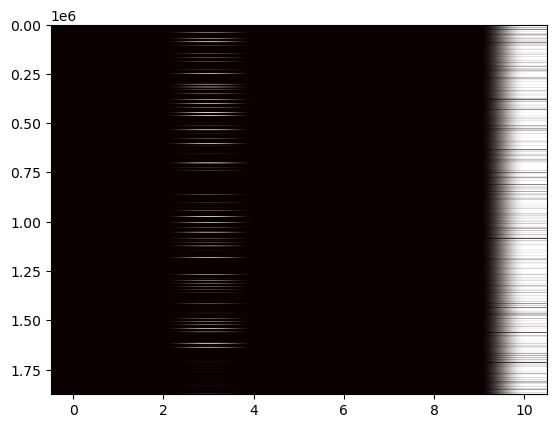

In [8]:
plt.imshow(df[student_feats].isnull(), cmap='hot', aspect='auto')

There are a few missing `imd_band`s and lots of missing `date_unregistration`s.

In [9]:
def how_missing(feature, df):
    m = sum(df[feature].isnull())
    return (m, f"{(m / len(df)):.4f}")

In [10]:
print(how_missing('imd_band',df),  how_missing('date_unregistration',df))

(98792, '0.0527') (1706150, '0.9097')


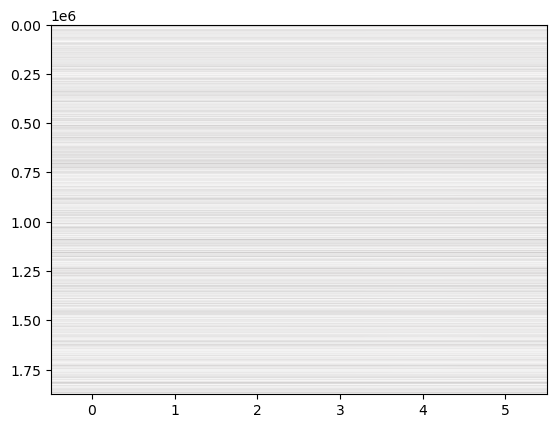

In [11]:
plt.imshow(df[assess_feats].isnull(), cmap='hot', aspect='auto')

Lots of missing `assess_feats`; it seems all these correspond to data lines where students have VLE-type interactions but not assessment interactions.

In [12]:
print(how_missing('id_assessment',df),  how_missing('assessment_type', df), how_missing('score',df))

(1701584, '0.9073') (1701584, '0.9073') (1701757, '0.9074')


In [13]:
df[df.id_assessment.isnull() & ~df.score.isnull()]

,id_student,code_module,code_presentation,date,forumng,homepage,oucontent,subpage,url,resource,...,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration


This resolves the mystery of the missing `score` fields: `score`s come from assessments; the small number of rows which are missing `score`s but not other `assess_feat` features probably come from students who did / submitted an assignment but did not receive a score on it for various reasons. We remark that these are all tutor-marked modules, across all modules and all presentations. 

In [14]:
df[~df.id_assessment.isnull() & df.score.isnull()].assessment_type.describe()

count     173
unique      1
top       TMA
freq      173
Name: assessment_type, dtype: object

In [15]:
df[~df.id_assessment.isnull() & df.score.isnull()].code_module.describe()

count     173
unique      7
top       BBB
freq       53
Name: code_module, dtype: object

In [16]:
df[~df.id_assessment.isnull() & df.score.isnull()].code_presentation.describe()

count       173
unique        4
top       2013B
freq         48
Name: code_presentation, dtype: object

For ease of processing (especially given the structure of the missing features), I am going to split into VLE and assessment dataframes. We will want to keep student data in both.

In [17]:
common_feats = list(tag_feats) + list(student_feats) + list(module_feats) + list(dataline_feats)
df_vle = df[df.id_assessment.isnull()][common_feats + list(vle_feats)]
df_assess = df[~df.id_assessment.isnull()][common_feats + list(assess_feats)]

In [18]:
df_vle[vle_feats].sample(3)

,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,repeatactivity,folder,htmlactivity
191267,14,5,13,1,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0
109708,0,1,3,15,0,3,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0
573464,0,4,1,3,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0


In [19]:
df_assess.sample(3)


,id_student,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,date_registration,date_unregistration,module_presentation_length,date,id_assessment,is_banked,score,assessment_type,due_date,weight
1126664,608243,EEE,2013J,M,South Region,A Level or Equivalent,80-90%,0-35,0,60,...,-35.0,NaN,268,67.0,30710.0,0.0,98.0,TMA,68.0,28.0
232942,357219,FFF,2013B,F,London Region,A Level or Equivalent,50-60%,0-35,1,120,...,-21.0,NaN,240,19.0,34860.0,0.0,92.0,TMA,19.0,12.5
1614006,693160,FFF,2014J,M,Yorkshire Region,Lower Than A Level,80-90%,0-35,0,60,...,-28.0,NaN,269,134.0,34902.0,0.0,74.0,TMA,136.0,25.0


**Aggregation strategy**

For the rest of the notebook, we will look at data aggregated at three levels: (i) for the first week; (ii) for the first three weeks; (iii) for the first third of the presentation.

*First-week data*

We next merge all data rows correspond to each (student, module, presentation).

In [20]:
df1w_vle = df_vle[df_vle.date<8].drop(['date'], axis=1)
X1 = df1w_vle.drop(student_feats,axis=1).groupby(list(tag_feats)).sum()
X2y = df1w_vle[list(tag_feats)+list(student_feats)].groupby(list(tag_feats)).last()
df1w_vle = pd.concat([X1,X2y],axis=1)

In [21]:
vle_feats

Index(['forumng', 'homepage', 'oucontent', 'subpage', 'url', 'resource',
       'glossary', 'dataplus', 'oucollaborate', 'quiz', 'ouelluminate',
       'sharedsubpage', 'questionnaire', 'page', 'externalquiz', 'ouwiki',
       'dualpane', 'repeatactivity', 'folder', 'htmlactivity'],
      dtype='object')

In [22]:
df1w_vle[vle_feats].sample()

,,,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,repeatactivity,folder,htmlactivity
id_student,code_module,code_presentation,,,,,,,,,,,,,,,,,,,,
590870,BBB,2014B,103,3,1,8,2,4,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0


**Correlations**

We next look at correlations between the interaction features, and then between engineered features (and interaction features).

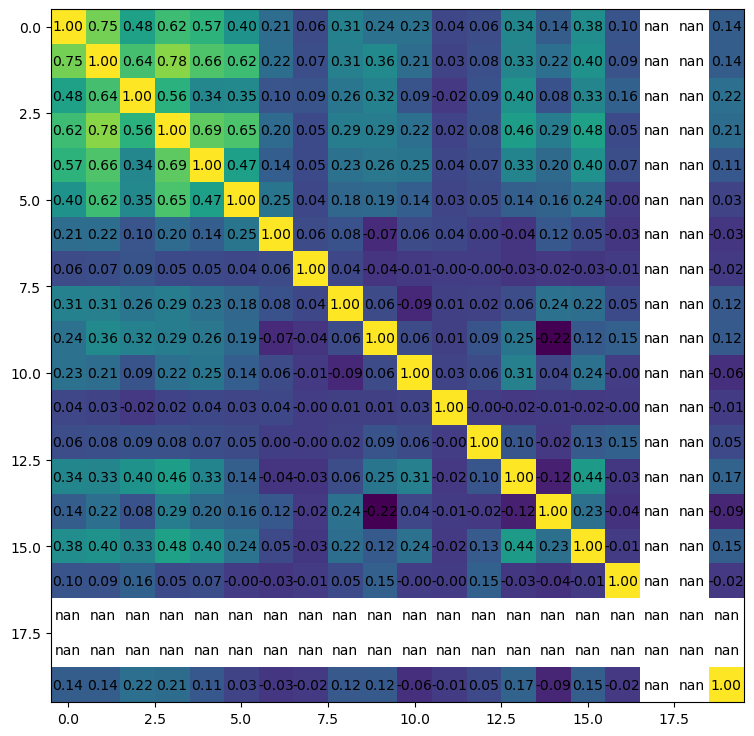

In [23]:
corrs = df1w_vle[vle_feats].corr(method='spearman')

plt.figure(figsize=(9,9))
plt.imshow(corrs, cmap='viridis')

for (j,i), label in np.ndenumerate(corrs):
    plt.text(i,j, f"{label:.2f}", ha='center', va='center', color='black')


#plt.imshow(corrs)
#df1w_vle[vle_feats].corr()

 The first six features appear relatively correlated with each other. `homepage` (the second feature) and `subpage` (the fourth feature), in particular, appear quite correlated with a number of other features and possibly should be disregarded (or maybe `homepage` should maybe be read as a sort of "total interaction" feature and is maybe redundant if we include `subpage` and/or `url`.). The remaining correlations do not seem too high. 

In [24]:
df1w_vle.repeatactivity.describe()

count    27112.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: repeatactivity, dtype: float64

In [25]:
df1w_vle.folder.describe()

count    27112.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: folder, dtype: float64

In [26]:
df[df.dataplus>0].groupby("id_student").sum().dataplus

id_student
6516       21
26192       9
26211      35
28061       7
28400      10
           ..
2689210    30
2689958     9
2691206     7
2692514     3
2697885    12
Name: dataplus, Length: 2697, dtype: int64

Two of these columns *never* appear (!); we should just drop these. (This also explains why the correlations with these columns are zero --- those columns have zero variance!)

In [27]:
df1w_vle.drop(['folder','repeatactivity'],axis=1,inplace=True)

**Engineered features** 

Now we add engineered features.

In [28]:
vle_feats_n = list(vle_feats[:-3]) + [vle_feats[-1]]
df1w_vle['total_vle']=df1w_vle[vle_feats_n].sum(axis=1)

In [29]:
df1w_vle['vle_richness'] = (df1w_vle[vle_feats_n] > 0).sum(axis=1)


In [30]:
from scipy.stats import entropy

def shannon_entropy(row):
    counts = row.values.astype(float)
    counts = counts[counts > 0]
    if len(counts) == 0:
        return 0
    proportions = counts / counts.sum()
    return entropy(proportions, base=2)

df1w_vle['vle_entropy'] = df1w_vle[vle_feats_n].apply(shannon_entropy, axis=1)

In [31]:
# Categorize VLE types
assessment_types = ['quiz', 'questionnaire', 'externalquiz']
content_types = ['oucontent', 'page', 'resource', 'url', 'homepage']
collaborative_types = ['forumng', 'oucollaborate', 'ouelluminate', 'ouwiki']

#student_totals = df.groupby(['id_student', 'code_module', 'code_presentation'])[vle_feats_n].sum()

# Assessment focus
df1w_vle['assessment_focus'] = df1w_vle[assessment_types].sum(axis=1) / df1w_vle.total_vle
df1w_vle['content_focus'] = df1w_vle[content_types].sum(axis=1) / df1w_vle.total_vle
df1w_vle['collab_focus'] = df1w_vle[collaborative_types].sum(axis=1) / df1w_vle.total_vle
#collaborative_focus = collaborative_focus.fillna(0).rename('collaborative_focus_ratio')

In [32]:
df_assess["rel_submit_date"] = df_assess["due_date"] - df_assess["date"]
df_assess["submission_type"] = np.where(df_assess["rel_submit_date"] < 0, "Late", "Early")

In [33]:
cutoff = 8
assess_freq = df_assess[df_assess.date < cutoff].groupby(list(tag_feats)).size().rename('assess_freq')
avg_score = df_assess[df_assess.date < cutoff][list(tag_feats)+['score']].groupby(list(tag_feats)).mean()
avg_early = df_assess[df_assess.date < cutoff][list(tag_feats)+['rel_submit_date']].groupby(list(tag_feats)).mean()

submission_type_counts = (
    df_assess[(df_assess.date < cutoff) & (df_assess.assessment_type != "Exam")]
    .groupby(list(tag_feats)+["submission_type"])
    .size()
    .unstack(fill_value=0)  # columns will be 'Early' and 'Late'
)
if "Late" in submission_type_counts: 
    avg_early["prop_early"] = submission_type_counts["Early"] / (submission_type_counts["Early"] + submission_type_counts["Late"])
else: 
    avg_early["prop_early"] = 1

In [34]:
df1w_assess = pd.concat([assess_freq,avg_score,avg_early],axis=1)


In [35]:
df1w_assess.sample(3)

,,,assess_freq,score,rel_submit_date,prop_early
id_student,code_module,code_presentation,,,,
94961,AAA,2014J,1,74.0,20.0,1
1486048,BBB,2014J,1,1.0,15.0,1
473081,FFF,2013J,1,90.0,20.0,1


In [36]:
df1w = pd.concat([df1w_vle,df1w_assess],axis=1)

In [37]:
df1w = df1w.drop('module_presentation_length',axis=1)

In [38]:
df1w[vle_feats_n] = df1w[vle_feats_n].fillna(0)
zerofills = ['score','assess_freq','rel_submit_date',
             'assessment_focus','content_focus','collab_focus','total_vle',
             'vle_richness','vle_entropy','prop_early']
df1w[zerofills] = df1w[zerofills].fillna(0)
df1w = df1w[~df1w.gender.isna()]
df1w = df1w[~df1w.imd_band.isna()]

In [39]:
df1w.tail(3)

forumng  homepage  oucontent  \
id_student code_module code_presentation                                 
2698535    CCC         2014B                 84.0      35.0        4.0   
           EEE         2013J                  7.0       7.0       20.0   
2698588    BBB         2014J                  0.0       4.0        3.0   

                                          subpage  url  resource  glossary  \
id_student code_module code_presentation                                     
2698535    CCC         2014B                 15.0  1.0      10.0       0.0   
           EEE         2013J                  3.0  1.0       0.0       0.0   
2698588    BBB         2014J                  0.0  1.0       1.0       0.0   

                                          dataplus  oucollaborate  quiz  ...  \
id_student code_module code_presentation                                 ...   
2698535    CCC         2014B                   0.0            0.0  29.0  ...   
           EEE         2013J                   0.0            0.0   1.0  ...   
2698588    BBB         2014J                   0.0            0.0   0.0  ...   

                                          total_vle  vle_richness  \
id_student code_module code_presentation                            
2698535    CCC         2014B                  178.0           7.0   
           EEE         2013J                   39.0           6.0   
2698588    BBB         2014J                    9.0           4.0   

                                          vle_entropy  assessment_focus  \
id_student code_module code_presentation                                  
2698535    CCC         2014B                 2.098297          0.162921   
           EEE         2013J                 1.939340          0.025641   
2698588    BBB         2014J                 1.752715          0.000000   

                                          content_focus  collab_focus  \
id_student code_module code_presentation                                
2698535    CCC         2014B                   0.280899      0.471910   
           EEE         2013J                   0.717949      0.179487   
2698588    BBB         2014J                   1.000000      0.000000   

                                          assess_freq  score rel_submit_date  \
id_student code_module code_presentation                                       
2698535    CCC         2014B                      0.0    0.0             0.0   
           EEE         2013J                      0.0    0.0             0.0   
2698588    BBB         2014J                      0.0    0.0             0.0   

                                         prop_early  
id_student code_module code_presentation             
2698535    CCC         2014B                    0.0  
           EEE         2013J                    0.0  
2698588    BBB         2014J                    0.0  

[3 rows x 39 columns]

In [40]:
# Add (overall) regularity features
cutoff = 8

def std_regularity(df, student_id_col=list(tag_feats), date_col='date'):
    return df.groupby(student_id_col)[date_col].apply(
        lambda x: x.sort_values().diff().std())    

# Lower values = more regular logins
# Higher values = more intermittent/irregular
df1w["std_regularity"] = std_regularity(df[df.date < cutoff]).fillna(0)
df1w["days_active"] = df[df.date < cutoff].groupby(list(tag_feats)).date.nunique()


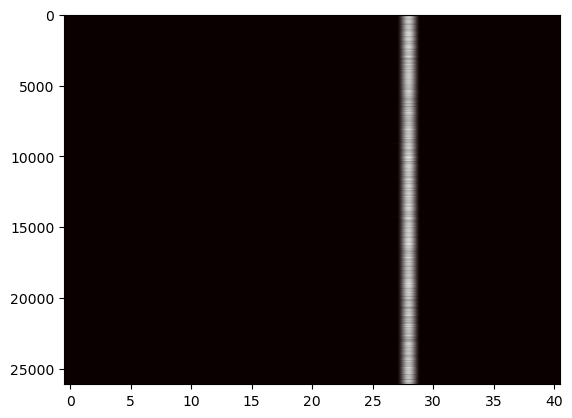

In [41]:
plt.imshow(df1w.isnull(), cmap='hot', aspect='auto')

Let us now examine correlation between engineered features (+ interaction features)

In [49]:
engineered_feats = df1w.columns[-12:]
engineered_feats

Index(['total_vle', 'vle_richness', 'vle_entropy', 'assessment_focus',
       'content_focus', 'collab_focus', 'assess_freq', 'score',
       'rel_submit_date', 'prop_early', 'std_regularity', 'days_active'],
      dtype='object')

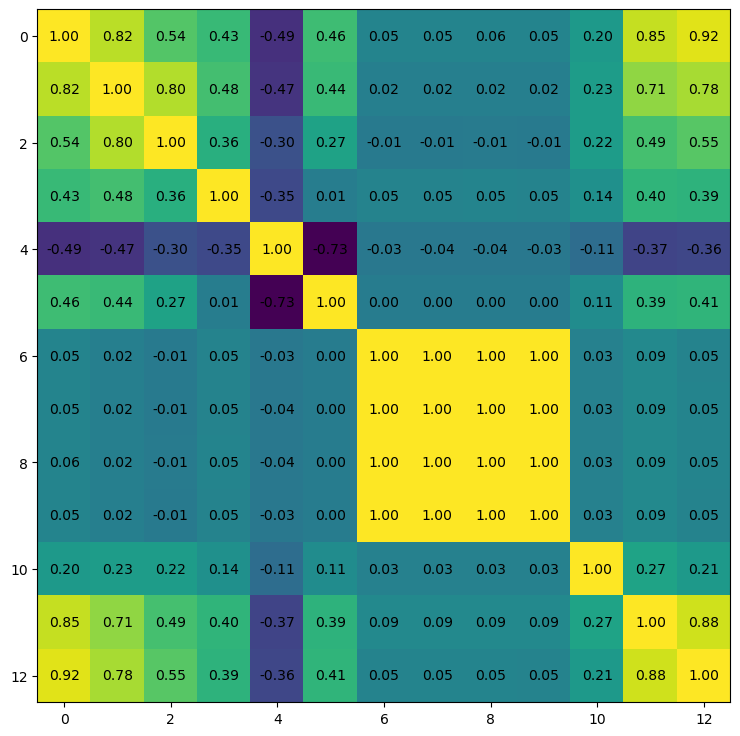

In [43]:
corrs = df1w[list(engineered_feats)+['homepage']].corr(method='spearman')

plt.figure(figsize=(9,9))
plt.imshow(corrs, cmap='viridis')

for (j,i), label in np.ndenumerate(corrs):
    plt.text(i,j, f"{label:.2f}", ha='center', va='center', color='black')


#plt.imshow(corrs)
#df1w_vle[vle_feats].corr()

We observe that `vle_total`, `vle_richness`, `days_active`, and `homepage` are all highly correlated. `vle_richness` is also quite correlated with `vle_entropy`. Maybe we can drop some of these features.

Also, the assessment features are all perfectly correlated with each other (using the Spearman coefficient). 

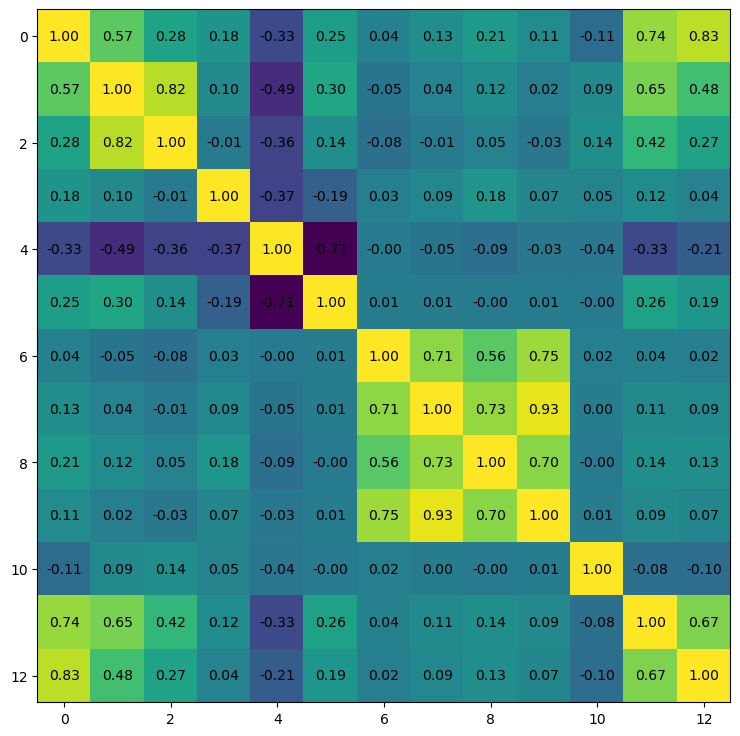

In [44]:
corrs = df1w[list(engineered_feats)+['homepage']].corr(method='pearson')

plt.figure(figsize=(9,9))
plt.imshow(corrs, cmap='viridis')

for (j,i), label in np.ndenumerate(corrs):
    plt.text(i,j, f"{label:.2f}", ha='center', va='center', color='black')

**Distribution of features**

We previously observed that the interaction features appear to be exponentially / geometrically distributed.

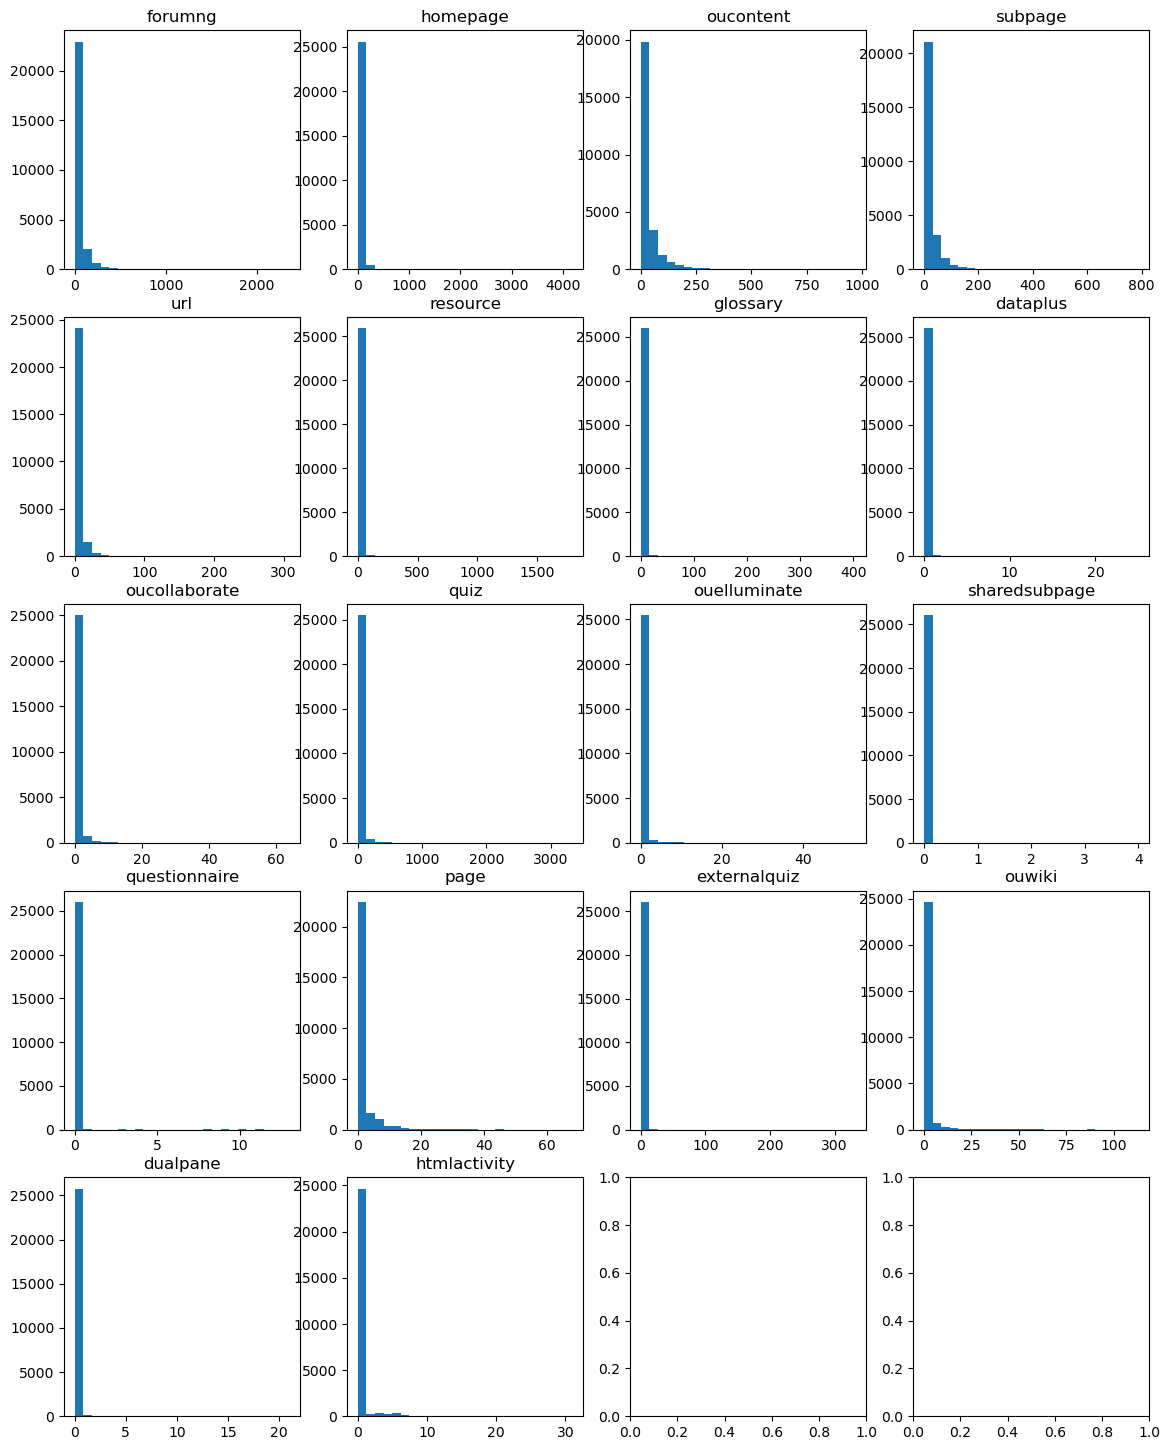

In [45]:
fig, axs = plt.subplots(nrows=5,ncols=4, figsize=(14,18))

for idx, feature in enumerate(df1w[vle_feats_n]): 
    y, x = idx//4, idx%4
    axs[y, x].hist(df1w[feature],bins=25)
    axs[y, x].set_title(feature)

In [46]:
n = len(df1w)
print("Feature / # / % of students with no instances")
for feature in vle_feats_n:
    z = df1w[feature]
    students_wo_feature = len(z[z==0])
    print(feature, "/", students_wo_feature, "/", students_wo_feature/n)

Feature / # / % of students with no instances
forumng / 7251 / 0.27787997240745
homepage / 185 / 0.007089752433509619
oucontent / 4765 / 0.18260902889553154
subpage / 4025 / 0.15425001916149306
url / 9522 / 0.3649114739020464
resource / 5026 / 0.19261132827469918
glossary / 23743 / 0.9099026596152372
dataplus / 25993 / 0.996129378401165
oucollaborate / 22758 / 0.8721545182800644
quiz / 18526 / 0.709971640990266
ouelluminate / 24881 / 0.9535142178278532
sharedsubpage / 26060 / 0.9986970184716794
questionnaire / 26021 / 0.9972024220127232
page / 20452 / 0.7837817122710201
externalquiz / 23237 / 0.8905112286349353
ouwiki / 22173 / 0.8497355713957232
dualpane / 25749 / 0.9867785697861577
htmlactivity / 24388 / 0.9346209856672032


What if we took logarithms?

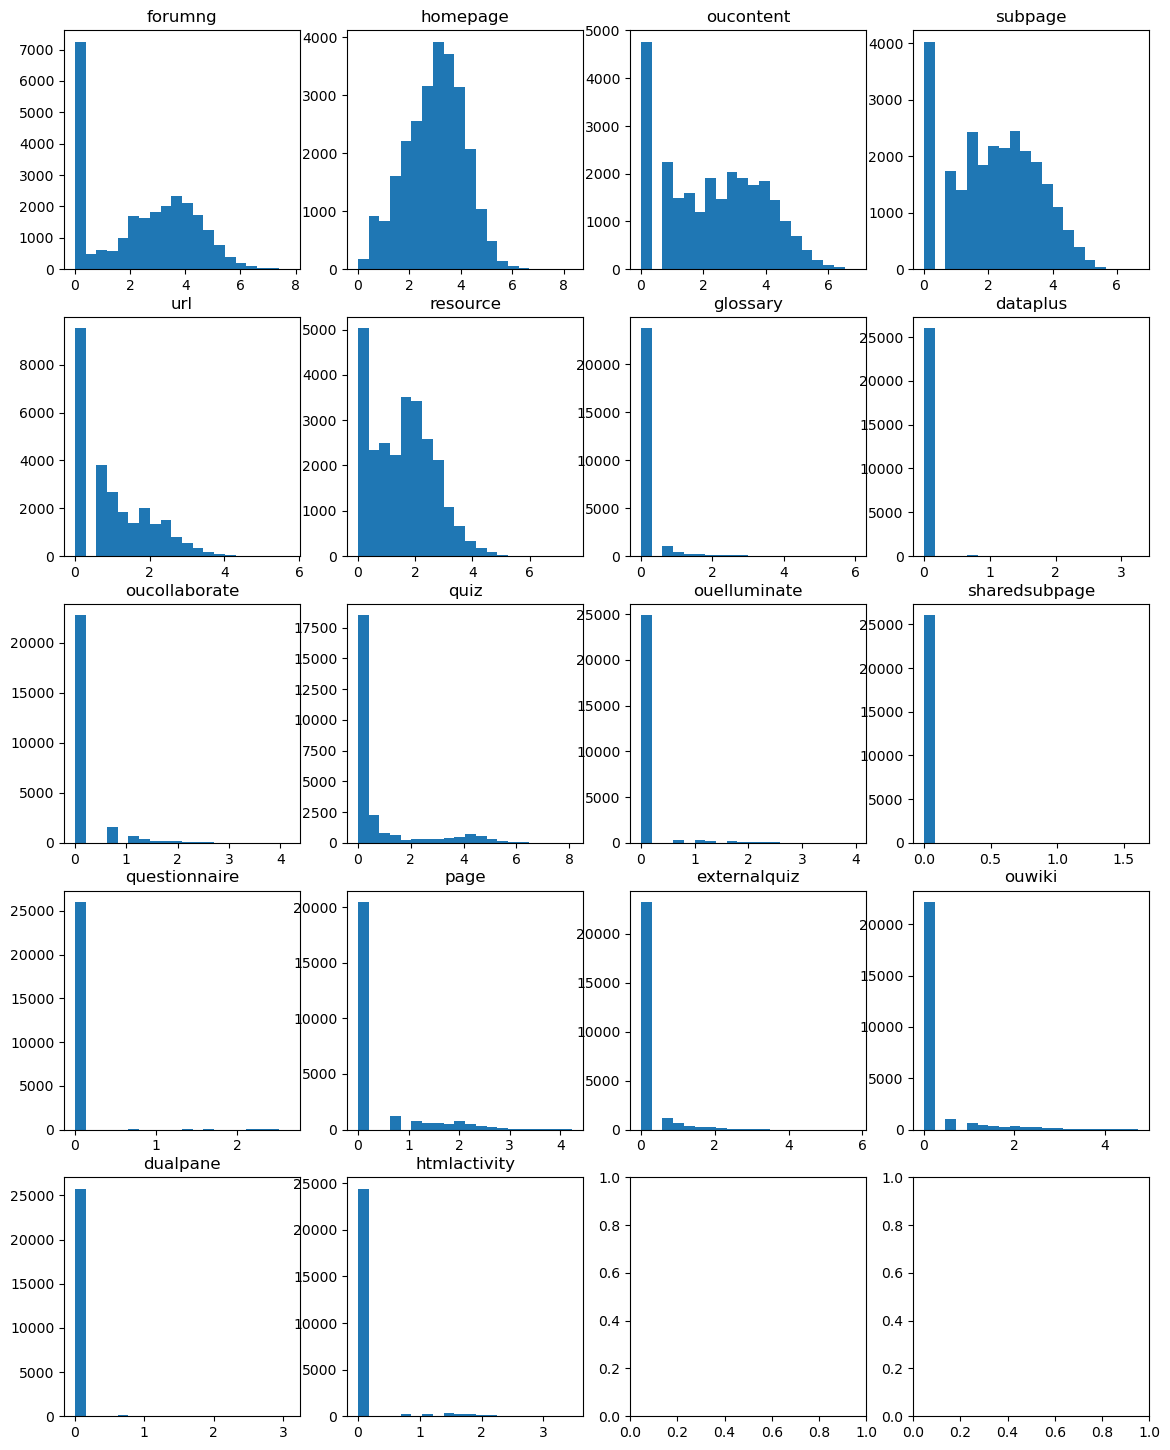

In [191]:
fig, axs = plt.subplots(nrows=5,ncols=4, figsize=(14,18))

for idx, feature in enumerate(df1w[vle_feats_n]): 
    y, x = idx//4, idx%4
    axs[y, x].hist((df1w[feature]+1).apply(np.log),bins=20)
    axs[y, x].set_title(feature)

I almost feels like it makes sense to discard the features with lots of zeros --- all but `forumng`,`homepage`, `oucontent`, `subpage`, `url`, `resource`. Maybe we can replace the other features with a simple 0 / 1 flag (did the student use the resource during the time period or not?)

**Distribution of features**

We next look at the distribution of engineered features.

In [47]:
len(engineered_feats)

12

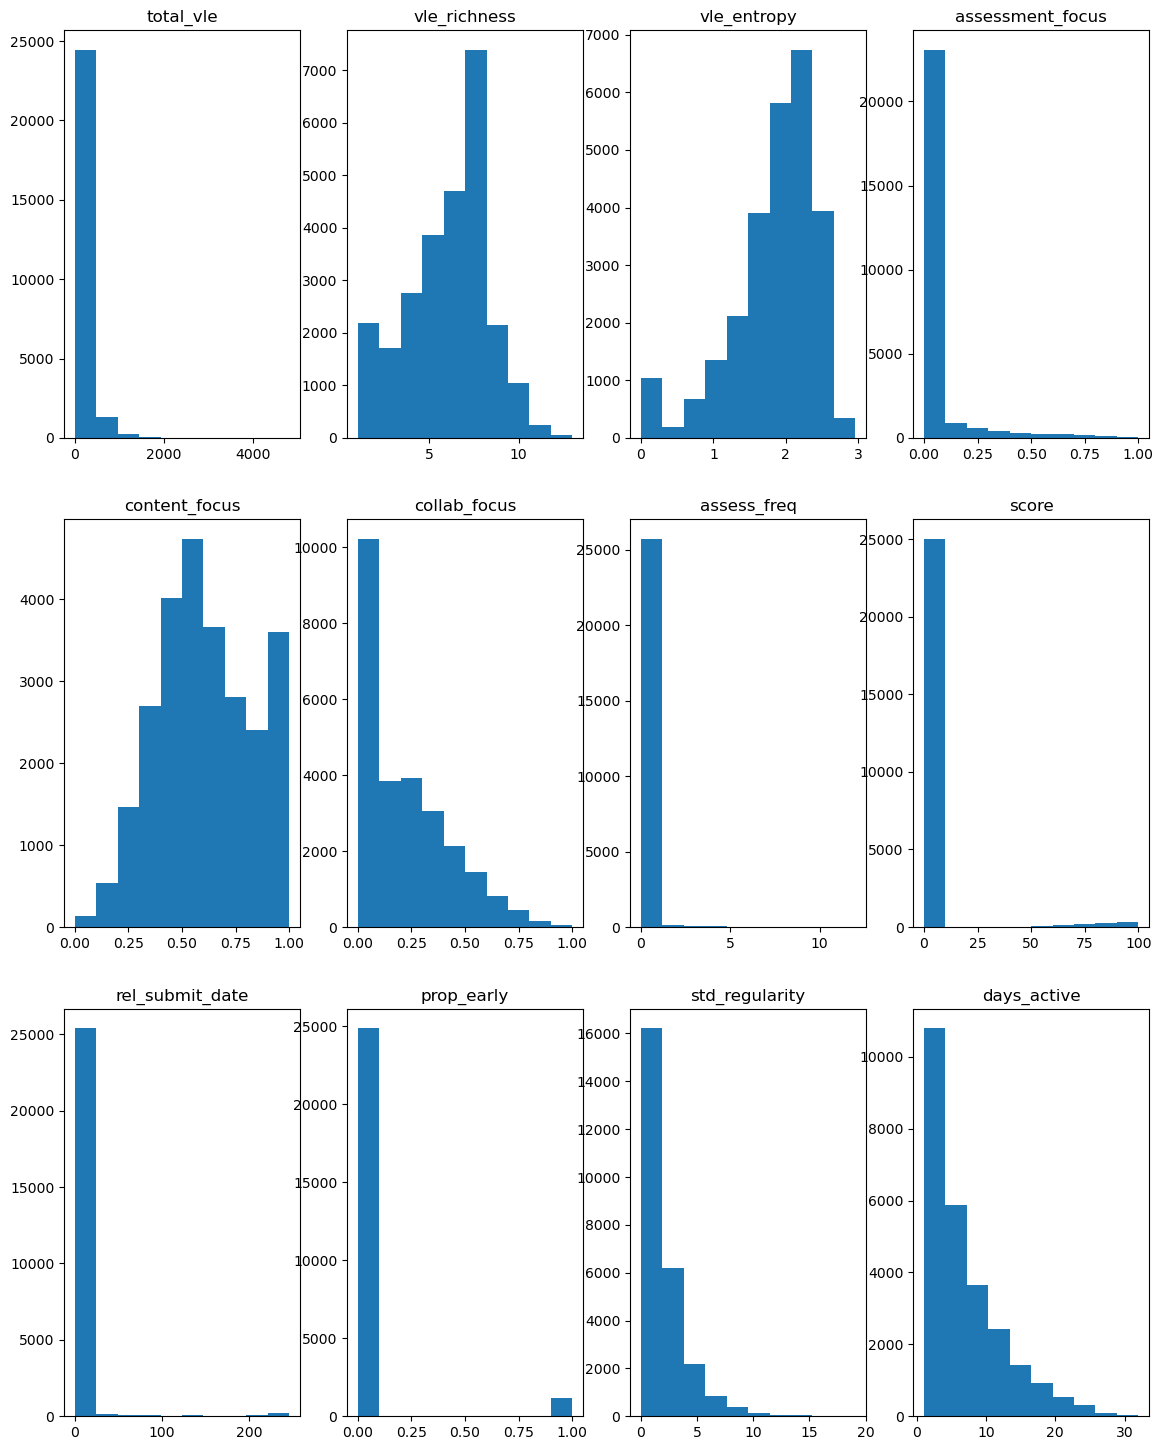

In [48]:
fig, axs = plt.subplots(nrows=3,ncols=4, figsize=(14,18))

for idx, feature in enumerate(df1w[engineered_feats]): 
    y, x = idx//4, idx%4
    axs[y, x].hist(df1w[feature])
    axs[y, x].set_title(feature)

Okay maybe I'll push the rest of the below to a new notebook ...

**Preprocessing**

- Drop all non-engineered VLE features except  `forumng`,`homepage`, `oucontent`, `subpage`, `url`, `resource`. 
- Drop `homepage`, `days_active`, and `vle_richness`.
- Take log for all remaining non-engineered VLE features, `total_vle`, `assess_freq`, `assessment_freq`, `std_regularity`, `rel_submit_date`? 
- Scale numeric values to be in range [0,1]
- Do one-hot encoding for categorical variables (student features)